# Bayesian Optimization

Imagine you need to find the best settings for a complex system – perhaps tuning the hyperparameters of a deep learning model, optimizing the design of an experiment, or finding the ideal parameters for a simulation. Often, evaluating the system with a given set of parameters (i.e., running the experiment or training the model) is expensive, time-consuming, or resource-intensive. How can you find the optimal settings without performing an exhaustive search?

This is where **Bayesian Optimization (BO)** comes in. It's a powerful, sequential strategy designed specifically for the **global optimization of black-box functions**. These are functions where:

1.  We don't know the underlying mathematical form (it's a "black box").
2.  Evaluating the function (getting an output `y` for an input `x`) is costly.
3.  We often cannot compute derivatives (gradients).
4.  The observations might be noisy (the output `y` can vary even for the same input `x`).

BO tackles this challenge by intelligently choosing the next point to evaluate, aiming to find the optimum (maximum or minimum) in as few evaluations as possible.

### Core Components

Bayesian Optimization cleverly balances exploring unknown parts of the search space and exploiting areas known to yield good results. It does this using two main components:

1.  **A Probabilistic Surrogate Model:** This model approximates the unknown objective function based on the points observed so far. It also provides uncertainty estimates about the function's behavior in unexplored regions. Gaussian Processes (GPs) are the most common choice for this surrogate model due to their flexibility and inherent uncertainty quantification.
2.  **An Acquisition Function:** This function uses the surrogate model's predictions (mean and uncertainty) to determine the 'utility' of evaluating any given point in the search space. It guides the search by suggesting the point that is most likely to lead to an improvement, considering both the predicted performance and the uncertainty. Examples include Expected Improvement (EI) and Upper Confidence Bound (UCB).

### The Iterative Process

The BO algorithm works iteratively:

1.  **Observe:** Evaluate the black-box function at one or more points chosen by the acquisition function.
2.  **Update:** Update the surrogate model (e.g., the Gaussian Process) using all the data collected so far (inputs and their observed outputs).
3.  **Select:** Optimize the acquisition function (which is cheap to evaluate) over the search space to find the most promising point(s) to evaluate next.
4.  **Repeat:** Continue this cycle until a stopping criterion is met (e.g., budget of function evaluations exhausted, desired performance level reached).


### Recommended reading:
1. [A Tutorial on Bayesian Optimization](https://arxiv.org/pdf/1807.02811)
1. [BayesOpt docs](https://bayesian-optimization.github.io/BayesianOptimization/2.0.3/)
1. [Exploring Bayesian Optimization](https://distill.pub/2020/bayesian-optimization/)
1. [Acquisition functions in Bayesian Optimization](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html)
1. [A Visual Exploration of Gaussian Processes](https://distill.pub/2019/visual-exploration-gaussian-processes/)
1. [Practical Bayesian Optimization of Machine Learning Algorithms](https://arxiv.org/abs/1206.2944)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition

# Set random seed for reproducibility
np.random.seed(42)

### Define and visualize the target function
First, we'll create a synthetic objective function to optimize. This specific function has three peaks (at x=0, x≈2 and x≈6) and is a toy example.

$$f(x) = e^{-(x - 2)^2} + e^{-\frac{(x - 6)^2}{10}} + \frac{1}{x^2 + 1}$$

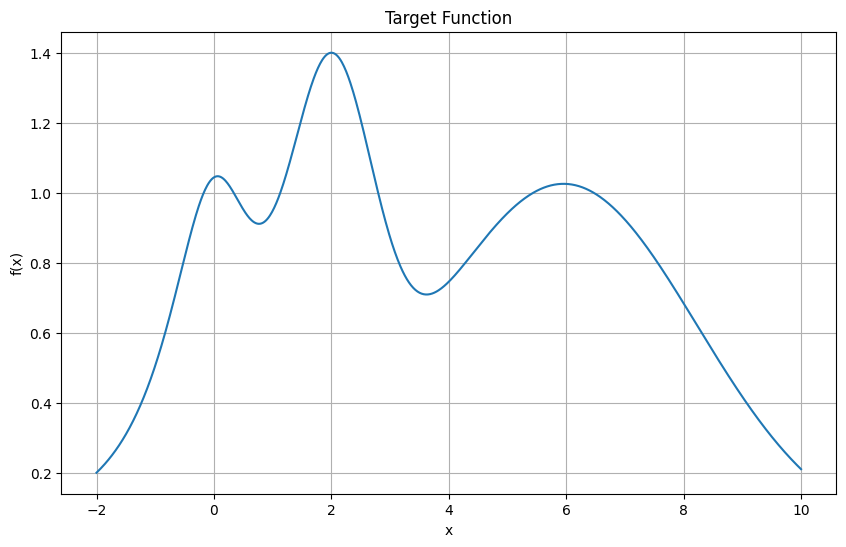

In [2]:
def target_function(x):
    """Our example target function to be optimized"""
    return np.exp(-((x - 2) ** 2)) + np.exp(-((x - 6) ** 2) / 10) + 1 / (x**2 + 1)


x = np.linspace(-2, 10, 1000)
y = target_function(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.grid(True)
plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### Define visualization functions
These helper functions will visualize the Gaussian Process model
and acquisition function at each step of the optimization process.
They help us understand how the model evolves as more observations are made.

In [3]:
def posterior(optimizer, grid):
    """Get posterior mean and standard deviation from GP model"""
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y, save_path=None):
    """Plot the Gaussian Process model, observations, and acquisition function"""
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        f"Gaussian Process and Utility Function After {steps} Steps",
        fontsize=30,
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label="Target")
    # debugging line for number of observations bc the plot was not showing all of them
    # print(f"Number of observations: {len(optimizer.res)}")
    axis.plot(
        x_obs.flatten(), y_obs, "D", markersize=6, label="Observations", color="r", alpha=0.6
    )
    
    # adding annotations to each obs point so as to be sure all of them plot correctly
    for i, (x_val, y_val) in enumerate(zip(x_obs.flatten(), y_obs)):
        axis.annotate(str(i+1), (x_val, y_val), xytext=(8, 8), textcoords='offset points', fontsize=8, color='red')
    
    axis.plot(x, mu, "--", color="k", label="Prediction")

    axis.fill(
        np.concatenate([x, x[::-1]]),
        np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=0.6,
        fc="c",
        ec="None",
        label="95% confidence interval",
    )

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel("f(x)", fontdict={"size": 20})
    axis.set_xlabel("x", fontdict={"size": 20})

    utility_function = optimizer.acquisition_function
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)
    x_flat = x.flatten()

    acq.plot(x_flat, utility, label="Utility Function", color="purple")
    acq.plot(
        x_flat[np.argmax(utility)],
        np.max(utility),
        "*",
        markersize=15,
        label="Next Best Guess",
        markerfacecolor="gold",
        markeredgecolor="k",
        markeredgewidth=1,
    )
    acq.set_xlim((-2, 10))
    acq.set_ylabel("Utility", fontdict={"size": 20})
    acq.set_xlabel("x", fontdict={"size": 20})

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

    return fig

We'll now see Bayesian Optimization in action, step by step.
At each step, observe:
1. How the GP model (dashed line) is updated
2. How the confidence interval (light blue area) changes
3. How the acquisition function (purple line) guides the next sample
4. Where the next sample point (gold star) is placed

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |

Step 0: Initial random points


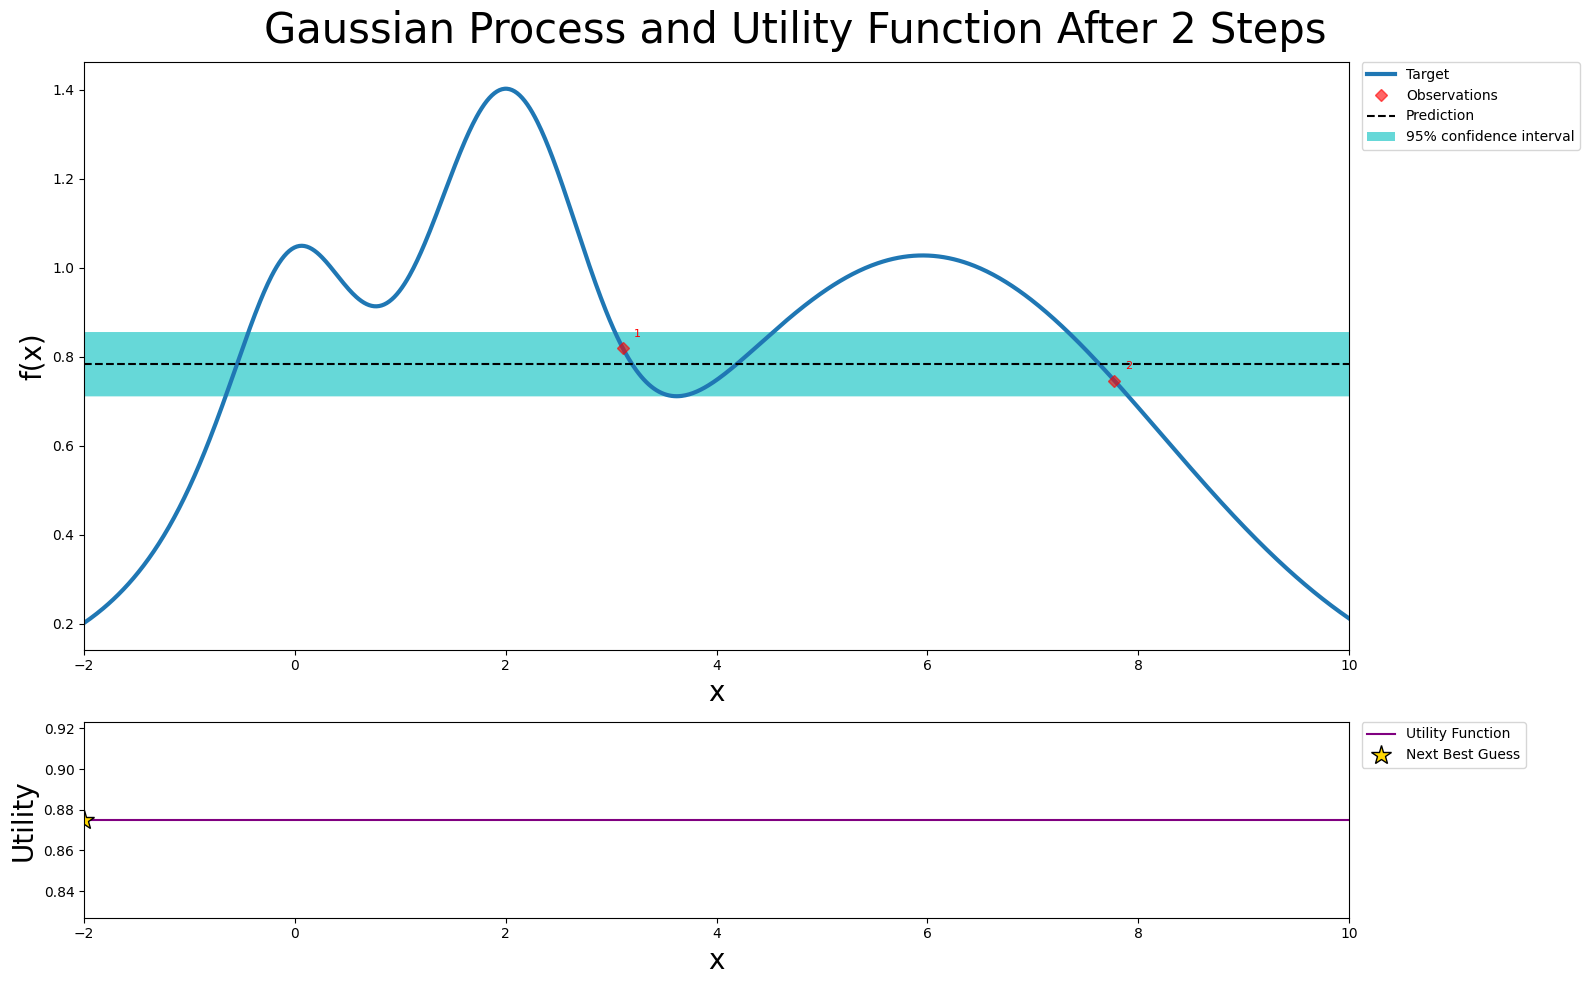

|   iter    |  target   |     x     |
-------------------------------------
| 3         | 0.8190422 | 3.1102721 |

Step 1: Added a new observation


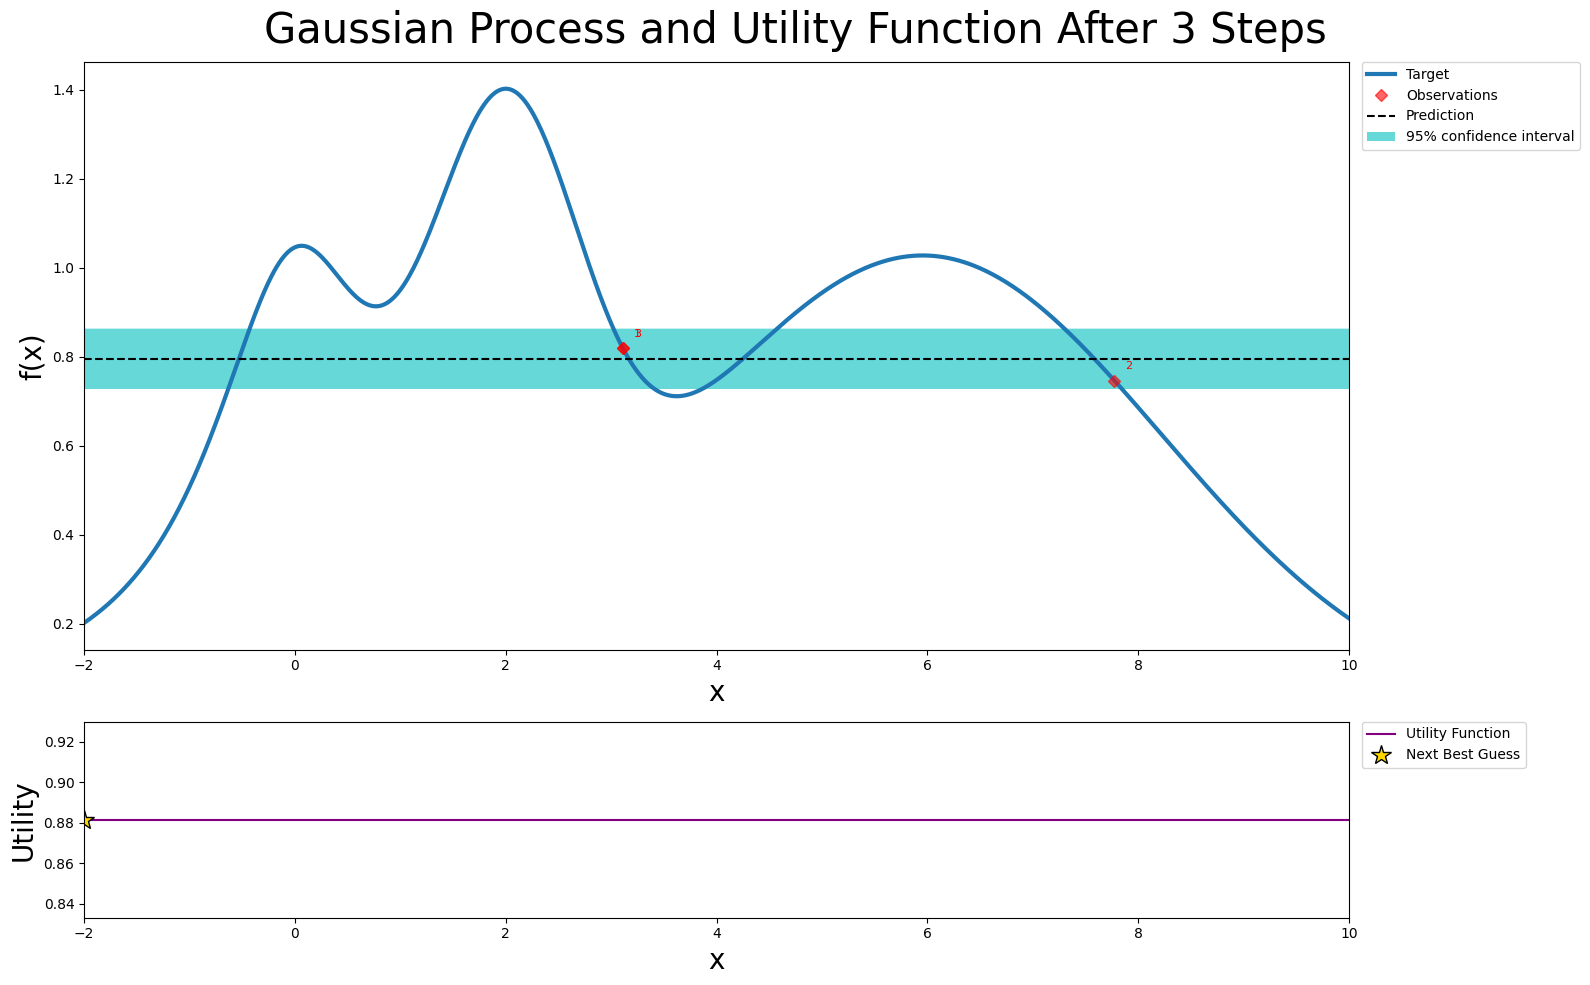

|   iter    |  target   |     x     |
-------------------------------------
| 4         | 0.8943137 | 2.9649330 |

Step 2: Added a new observation


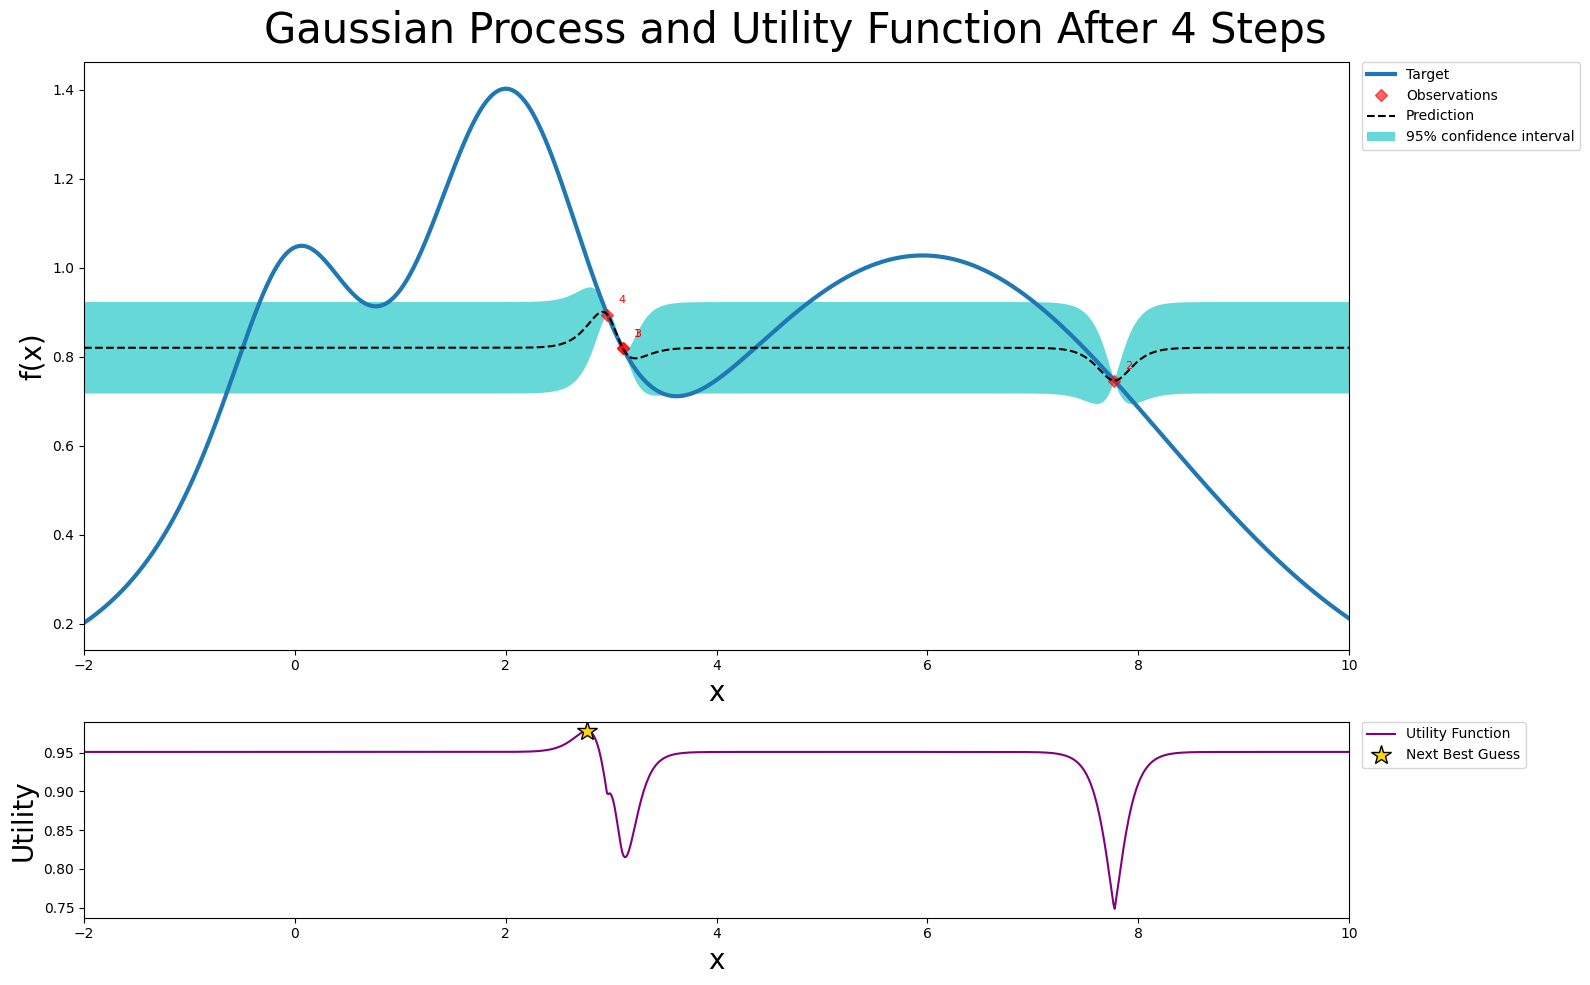

|   iter    |  target   |     x     |
-------------------------------------
| 5         | 1.0188851 | 2.7720553 |

Step 3: Added a new observation


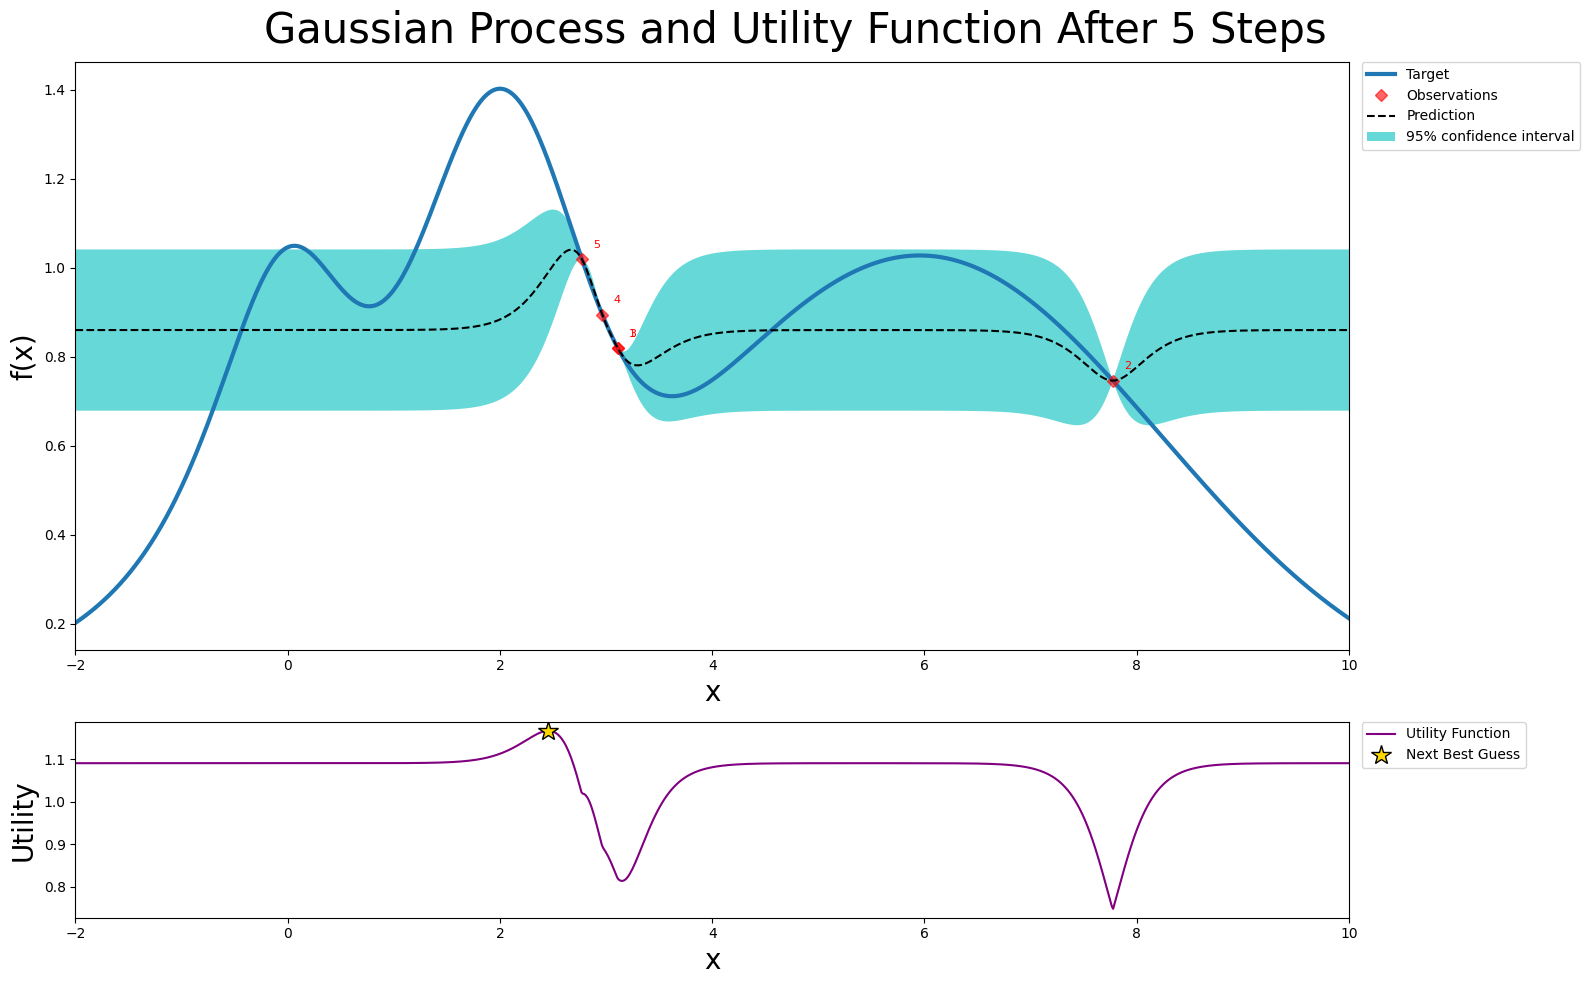

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 1.2389517 | 2.4564829 |

Step 4: Added a new observation


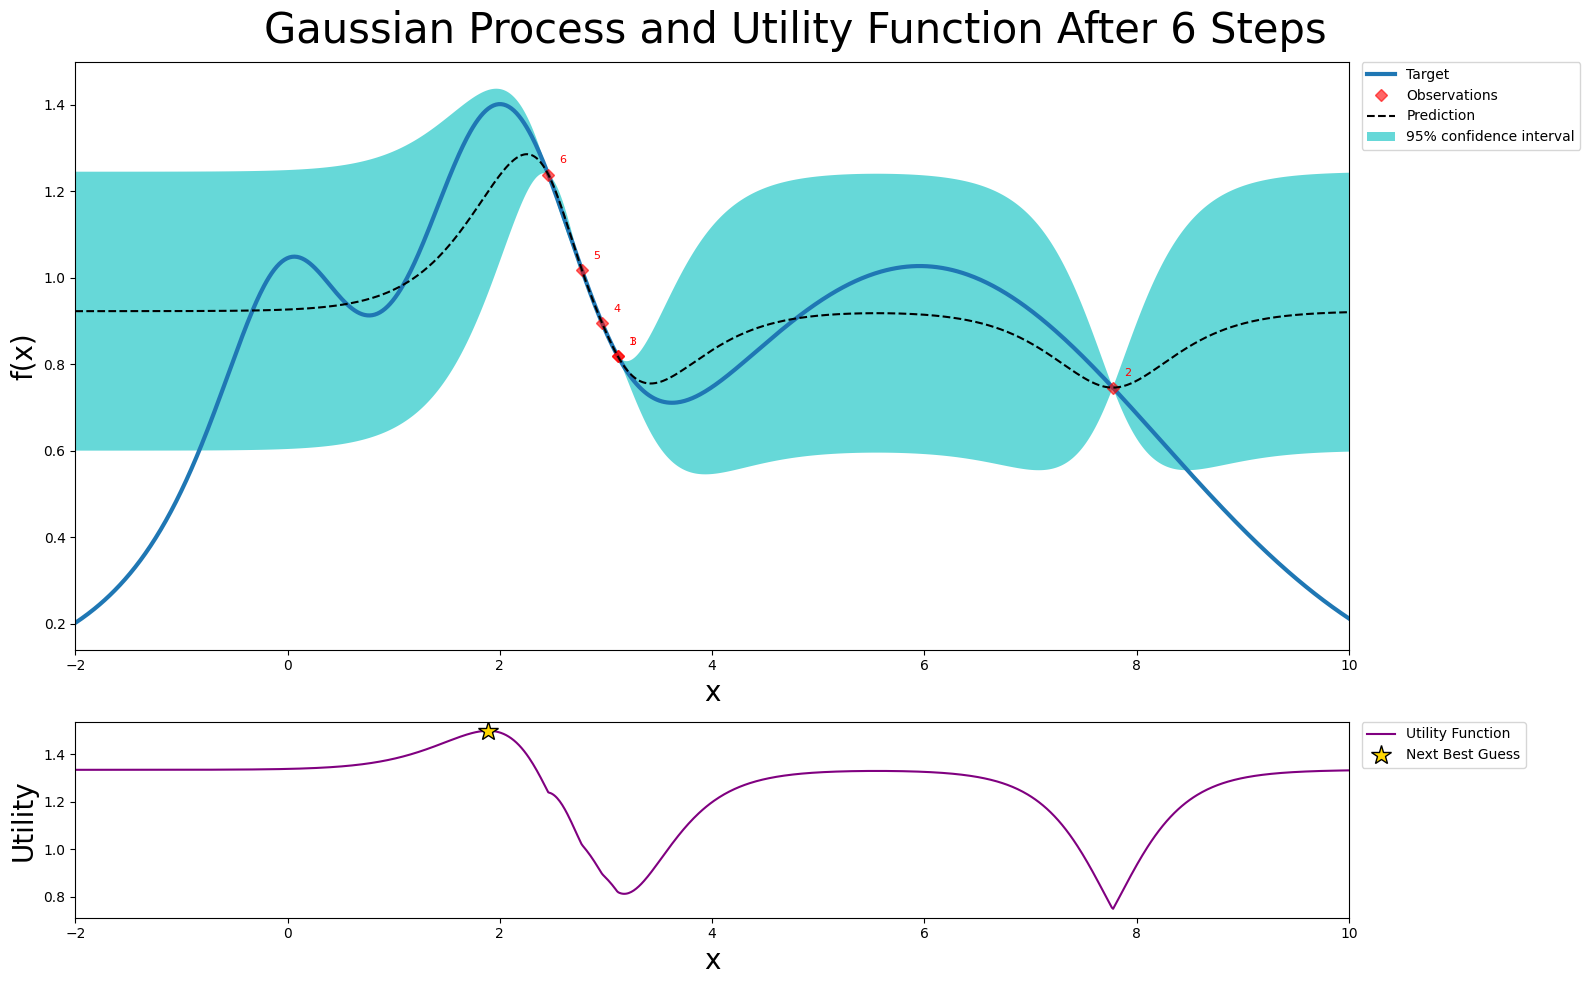

|   iter    |  target   |     x     |
-------------------------------------
| 7         | 1.3911164 | 1.8887341 |

Step 5: Added a new observation


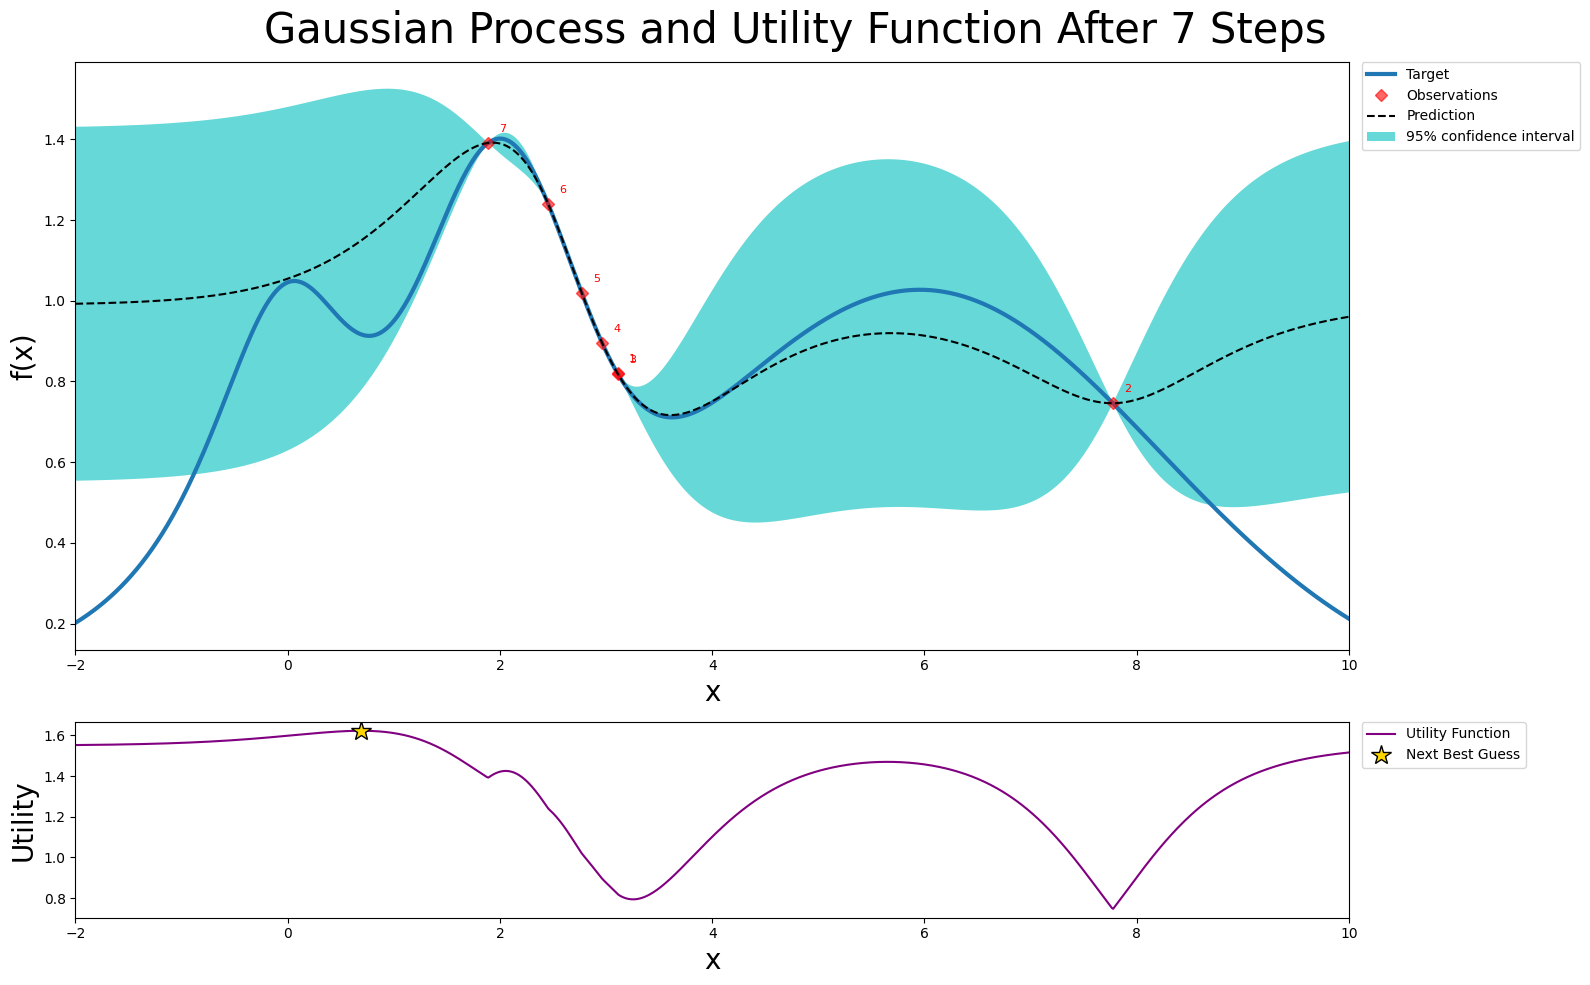


Final result:
Best target value found: 1.3911
Best input value found: x = 1.8887


In [4]:
acquisition_function = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=acquisition_function,
    random_state=27,
)

# Prepare data for visualization
x = np.linspace(-2, 10, 1000).reshape(-1, 1)
y = target_function(x)

# Initialize with 2 random points
optimizer.maximize(init_points=2, n_iter=0)
print("\nStep 0: Initial random points")
plot_gp(optimizer, x, y)

for i in range(1, 6):
    optimizer.maximize(init_points=0, n_iter=1)
    print(f"\nStep {i}: Added a new observation")
    plot_gp(optimizer, x, y)

print("\nFinal result:")
print(f"Best target value found: {optimizer.max['target']:.4f}")
print(f"Best input value found: x = {optimizer.max['params']['x']:.4f}")

## Comments
We can see the BO nearly found global maximum.

Acquisition functions guide the sampling process by balancing:
- Exploitation: Sampling where the model predicts high values
- Exploration: Sampling where the model is uncertain

We'll compare three different acquisition functions:
1. Upper Confidence Bound (UCB): Balances exploration and exploitation
2. Probability of Improvement (PI): More exploitative
3. Greedy: Purely exploitative (custom implementation)

In [5]:
class GreedyAcquisition(acquisition.AcquisitionFunction):
    """Purely exploitative acquisition function (only considers mean)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return mean  # disregard std

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856791 | -0.211777 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351178 | 4.9507547 |

UCB Acquisition Function Results:


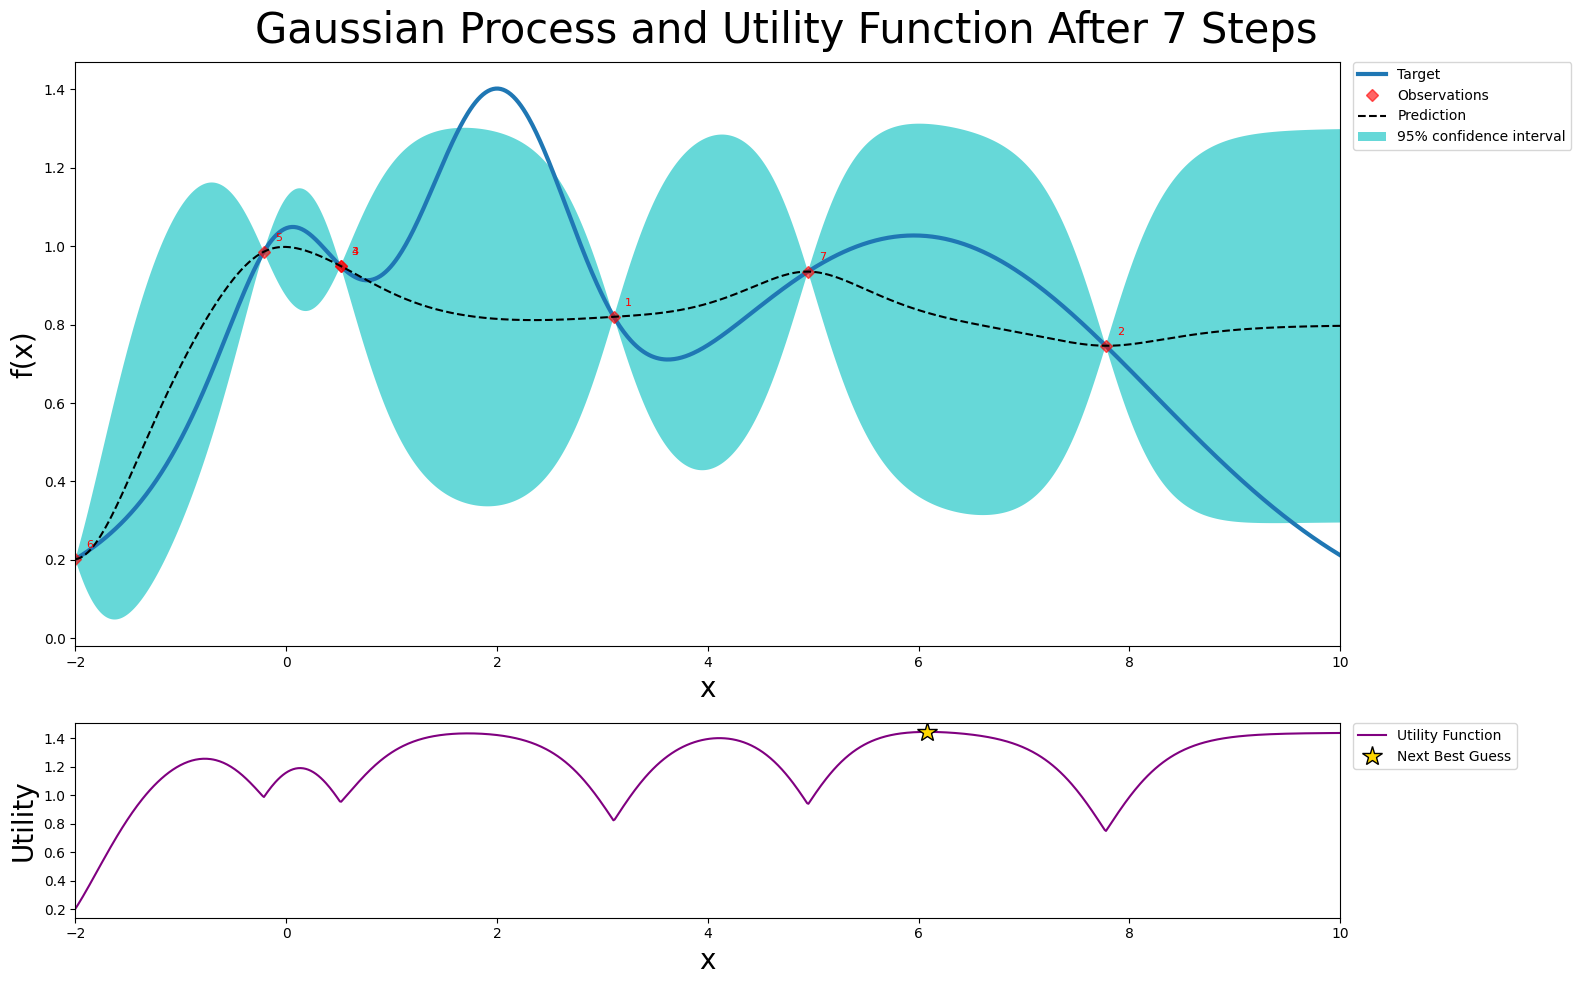

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

Probability of Improvement Acquisition Function Results:


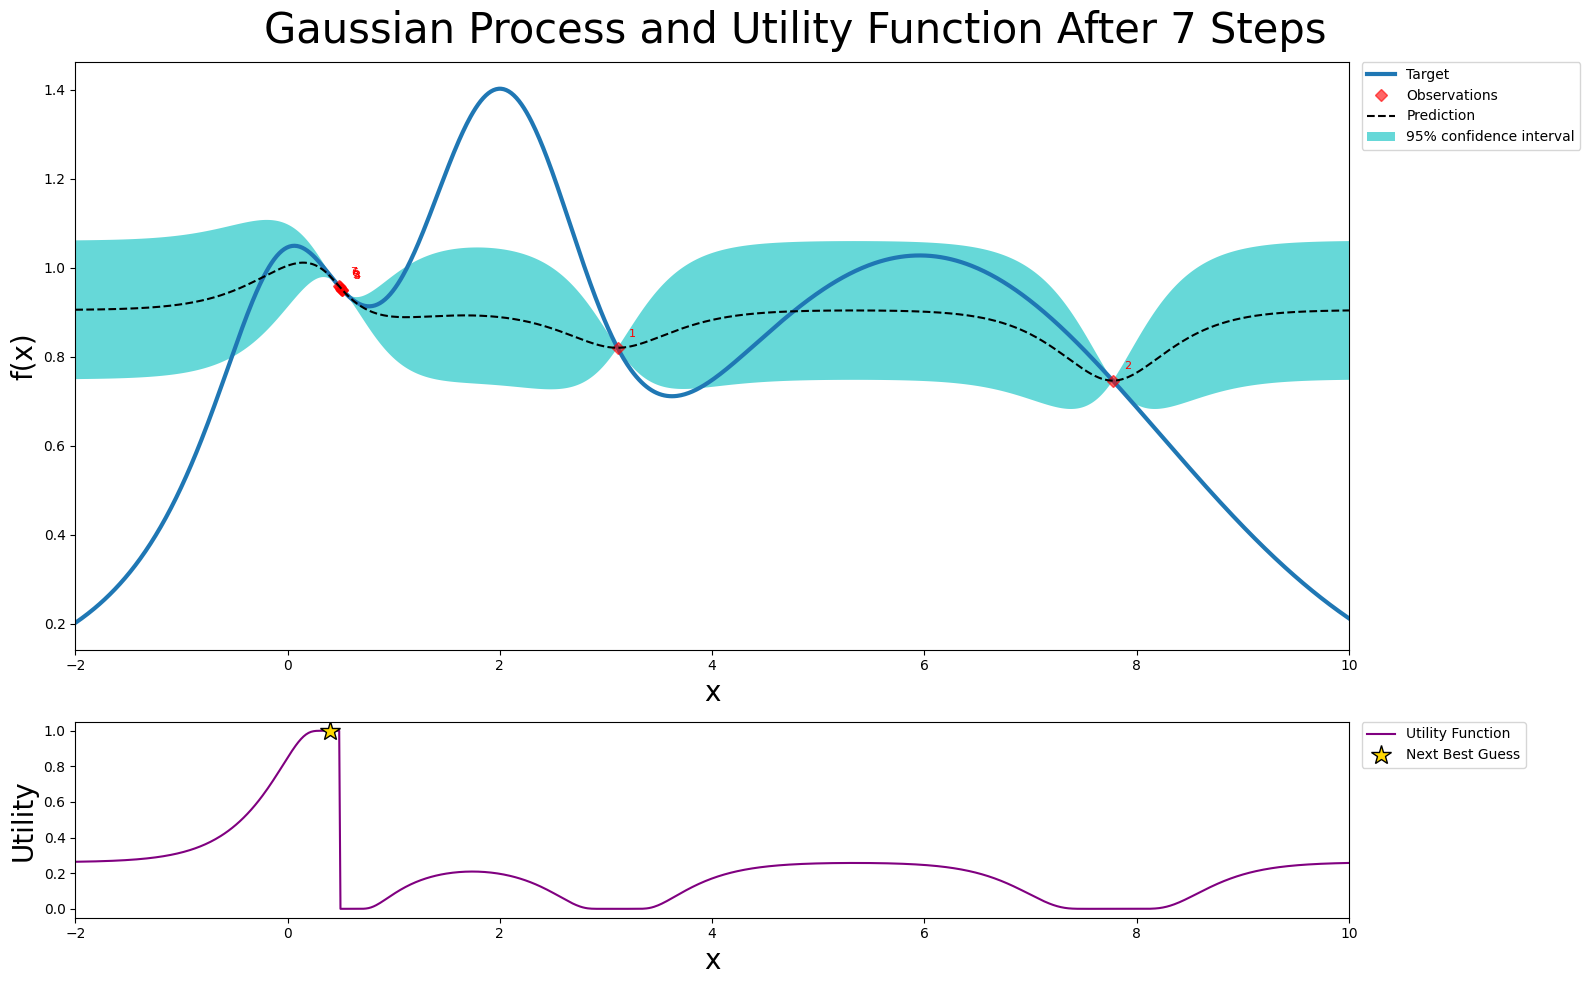

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495499 | 0.5165820 |
| 5         | 0.9495499 | 0.5165820 |
| 6         | 0.9495499 | 0.5165820 |
| 7         | 0.9495499 | 0.5165820 |

Greedy (Purely Exploitative) Acquisition Function Results:


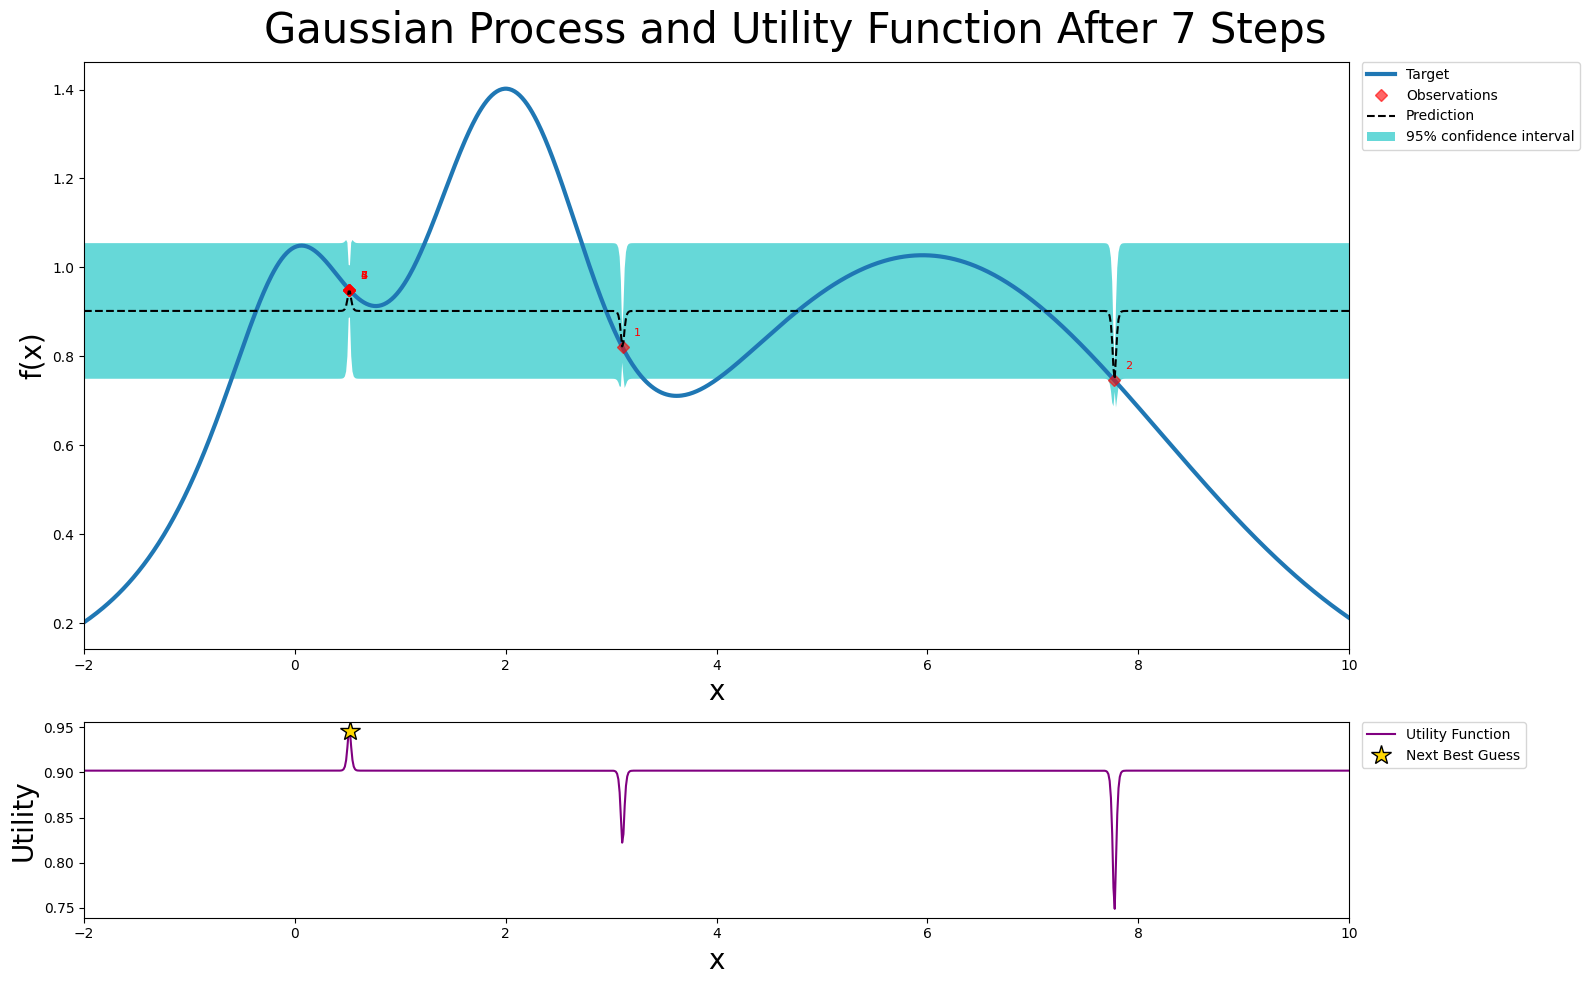


Summary of results:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Greedy best value: 0.9495 at x = 0.5166


In [6]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Greedy
greedy = GreedyAcquisition()
optimizer_greedy = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=greedy,
    random_state=27,
)

optimizer_greedy.maximize(init_points=2, n_iter=5)
print("\nGreedy (Purely Exploitative) Acquisition Function Results:")
plot_gp(optimizer_greedy, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Greedy best value: {optimizer_greedy.max['target']:.4f} at x = {optimizer_greedy.max['params']['x']:.4f}"
)

Comment these results. Write your observations in a Markdown cell.

## Comments
The Greedy acquisition function led to poor results. It is mainly a straight horizontal line.  
Gaussian Process has the widest confidence intervals. They are also shaped similar to normal distribution bell-shape. It is the most exploratory out of all processes. That is because of these wide confidence intervals which causes more uncertainty, so the exploration is higher.  
The PI and Greedy acquisition function point to the same three points over and over again in the whole process. Both are exploitative, so they converge to the same local optimum.
 

Exercise 1: UCB
---------------

The parameter kappa in the UCB acquisition function controls the trade-off between:
- Exploration (high kappa): More emphasis on the uncertainty
- Exploitation (low kappa): More emphasis on the predicted mean

Compare results for UCB using 3 different values:
1. kappa = 0.1 (Mostly exploitation)
2. kappa = 2.5 (Balanced)
3. kappa = 5.0 (Mostly exploration)

Review this [blog post](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html) and explain the underlying concept of UCB in a Markdown cell.

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495496 | 0.5165830 |
| 5         | 0.9561417 | 0.4919817 |
| 6         | 1.0125033 | 0.2974808 |
| 7         | 1.0463085 | 0.0066685 |

UCB (kappa=0.1) Acquisition Function Results:

Summary of results:
Best value: 1.0463 at x = 0.0067


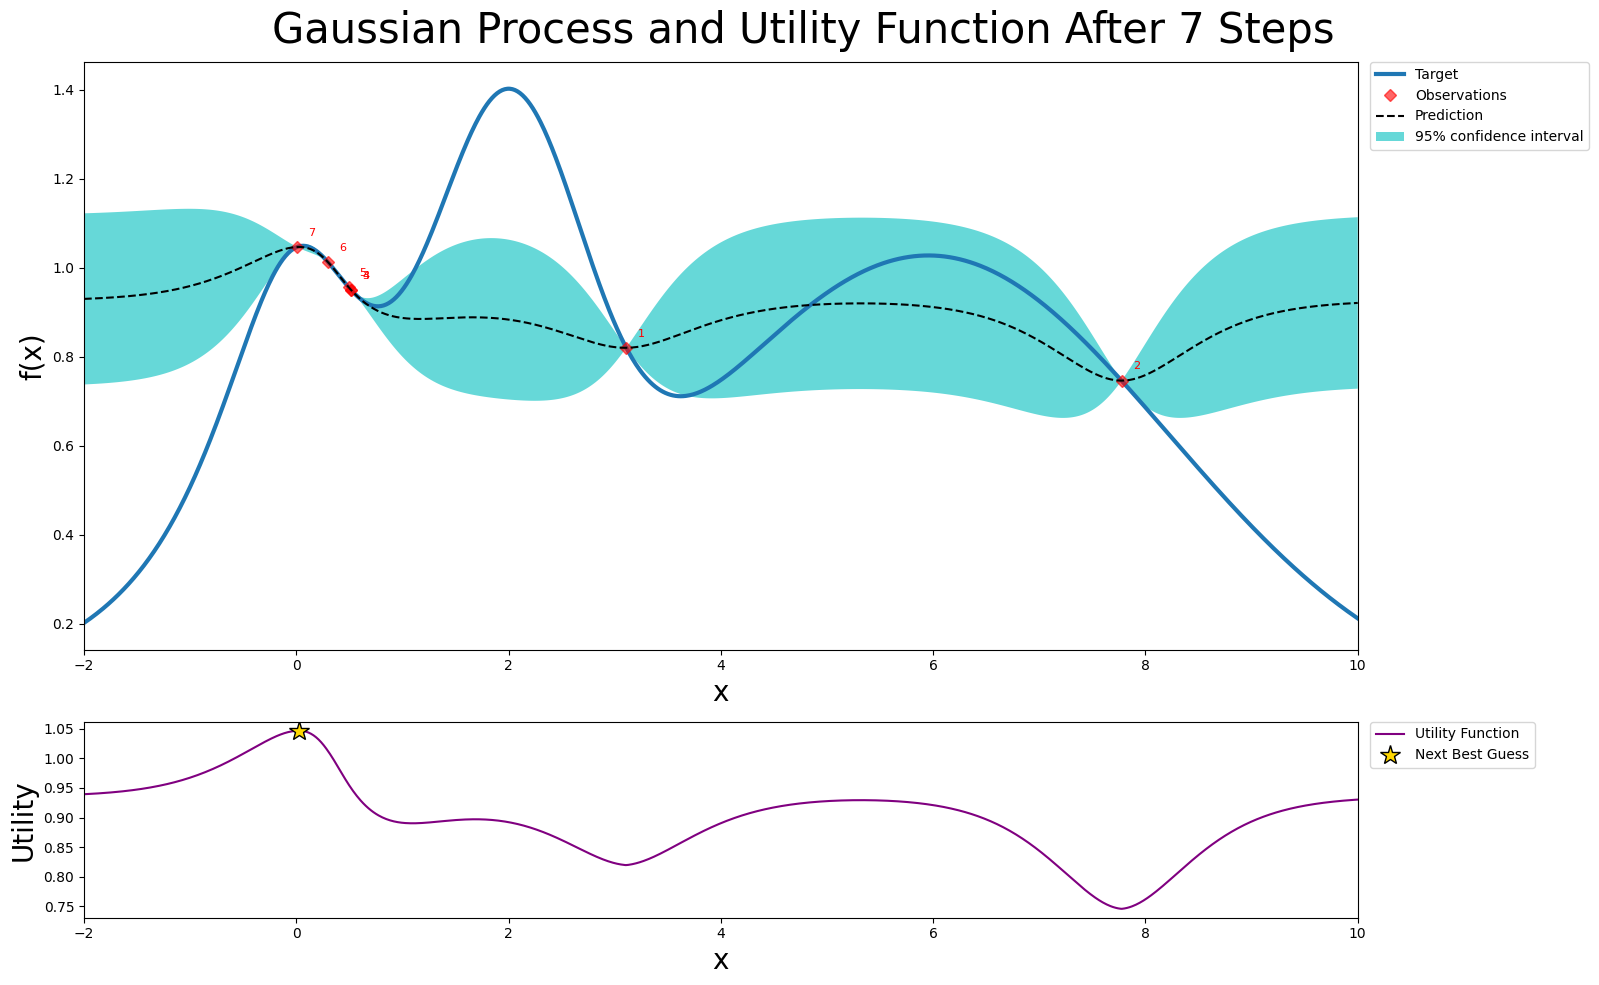

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856791 | -0.211777 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351178 | 4.9507547 |

UCB (kappa=2.5) Acquisition Function Results:

Summary of results:
Best value: 0.9857 at x = -0.2118


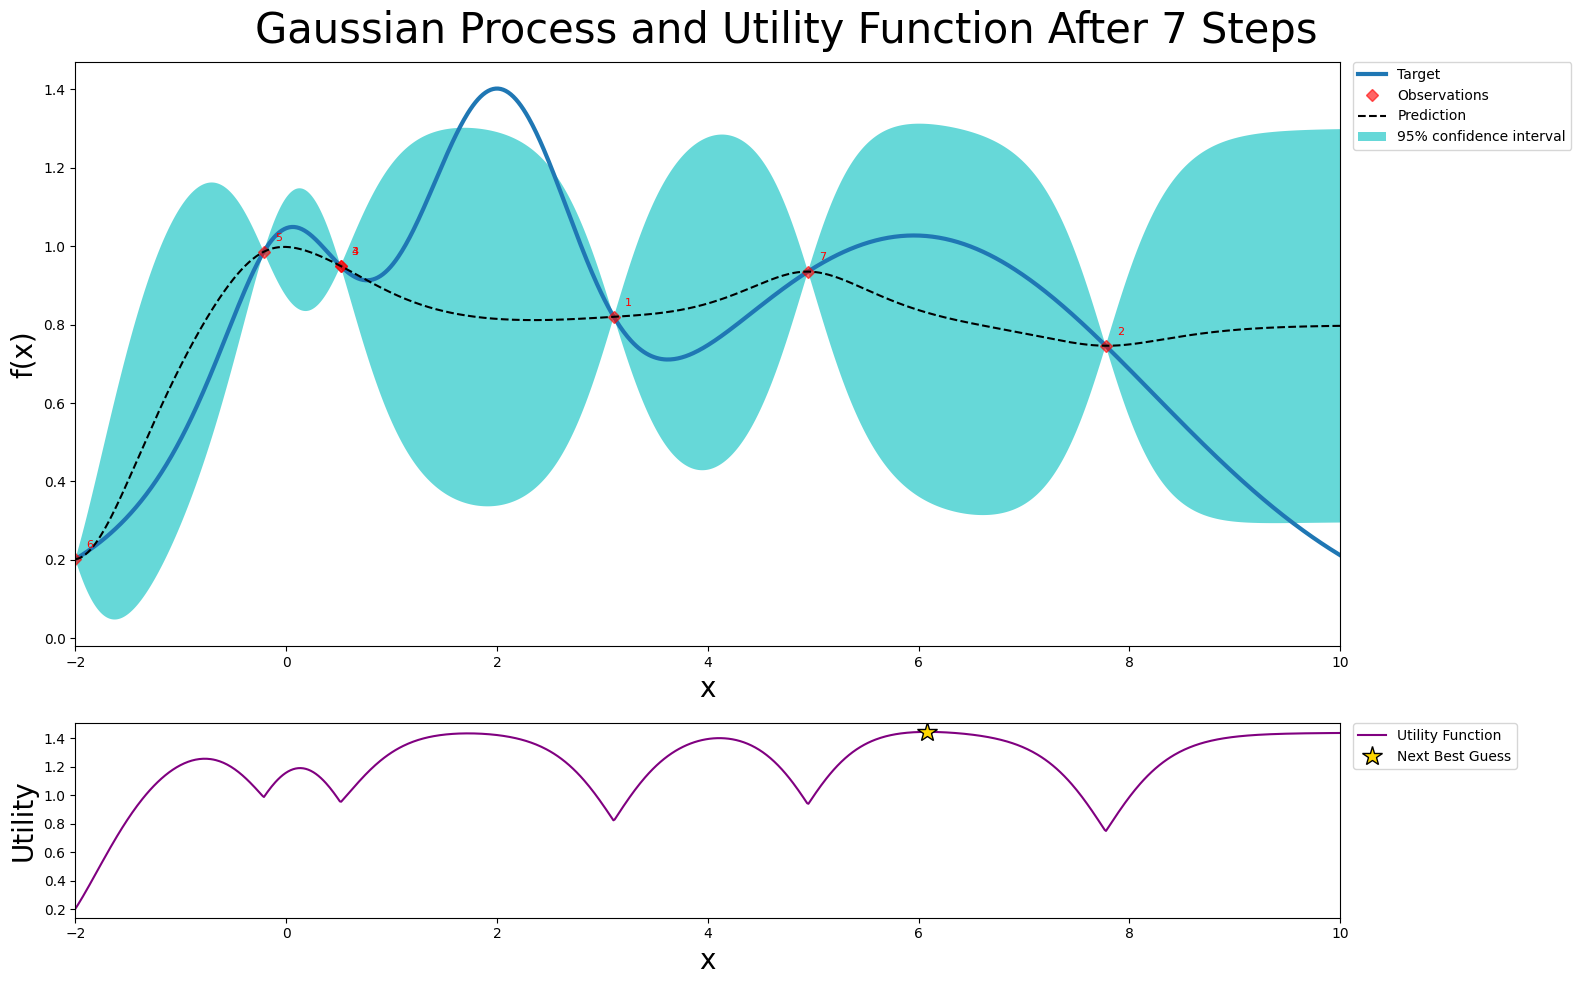

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.8354470 | -0.471613 |
| 6         | 0.9452205 | 0.9845857 |
| 7         | 0.2117975 | 10.0      |

UCB (kappa=5.0) Acquisition Function Results:

Summary of results:
Best value: 0.9496 at x = 0.5165


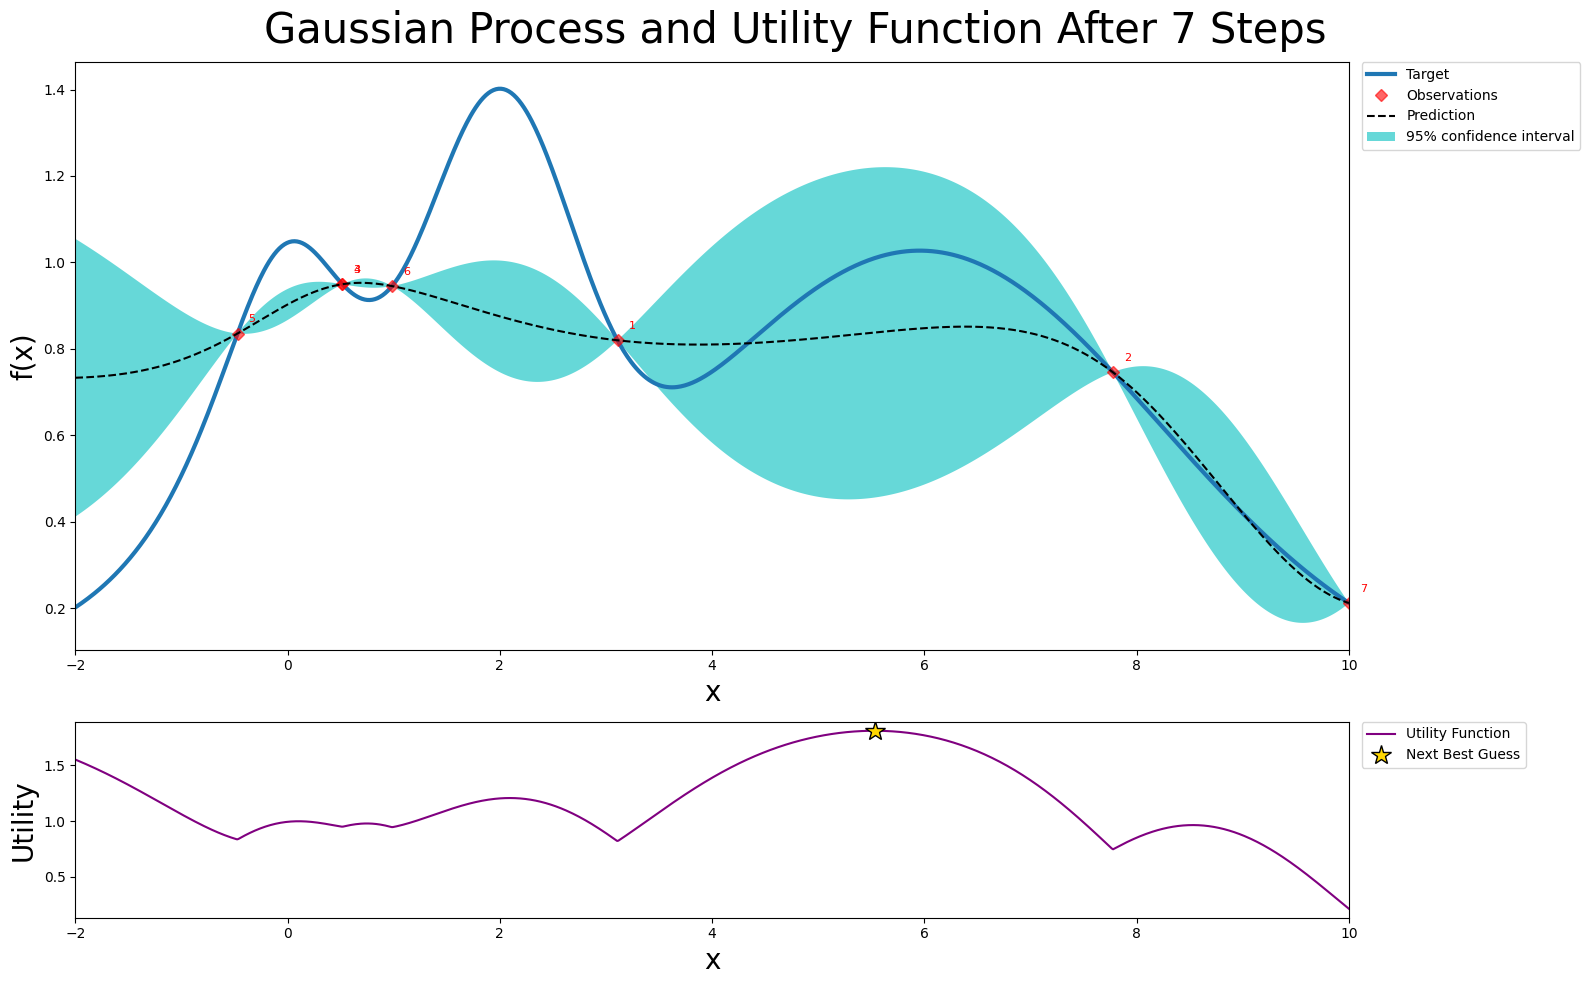

In [7]:
kappa_values = [0.1, 2.5, 5.0]
for kappa in kappa_values:
    ucb = acquisition.UpperConfidenceBound(kappa=kappa)
    optimizer_ucb = BayesianOptimization(
        f=target_function,
        pbounds={"x": (-2, 10)},
        acquisition_function=ucb,
        random_state=27,
    )

    optimizer_ucb.maximize(init_points=2, n_iter=5)
    print(f"\nUCB (kappa={kappa}) Acquisition Function Results:")
    print("\nSummary of results:")
    print(f"Best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}")
    plot_gp(optimizer_ucb, x, y)

## Comments on UCB

The Upper Confidence Bound acquisition function balances exploration and exploitation through the formula:

$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$

Where:
- $\mu(x)$ is the predicted mean (exploitation: favor high predicted values)
- $\sigma(x)$ is the predicted uncertainty (exploration: favor uncertain regions)
- $\kappa$ is the hyperparameter controlling the trade-off

From charts we can see that for kappa=0.1, after third step, the algorithm repeatedly samples near the third point (highest predicted value found in step 3). The confidence intervals for this method are very narrow. It quickly converges to local optimum. For kappa=5, the next steps seem totally random. For kappa=2.5 the algorithm is still a little too exploratory in my opinion.

Exercise 2: Chaotic Acquisition Function
-----------------------------------------
**Goal**: Implement a chaotic acquisition function that exclusively prioritizes the standard deviation of predictions, disregarding the predicted mean. Compare its performance against standard acquisition functions such as UCB and PI (Probability of Improvement).

In [8]:
class ChaoticAcquisition(acquisition.AcquisitionFunction):
    """Purely exploitative acquisition function (only considers mean)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return std  # disregard mean


|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495619 | 0.5165359 |
| 5         | 0.9856791 | -0.211777 |
| 6         | 0.2016616 | -2.0      |
| 7         | 0.9351178 | 4.9507547 |

UCB Acquisition Function Results:


<>:36: SyntaxWarning: invalid escape sequence '\C'
<>:36: SyntaxWarning: invalid escape sequence '\C'
/var/folders/mg/dphd82dn4z53n1pwgpjmb8600000gn/T/ipykernel_65413/2817151258.py:36: SyntaxWarning: invalid escape sequence '\C'
  print("\Chaotic Acquisition Function Results:")


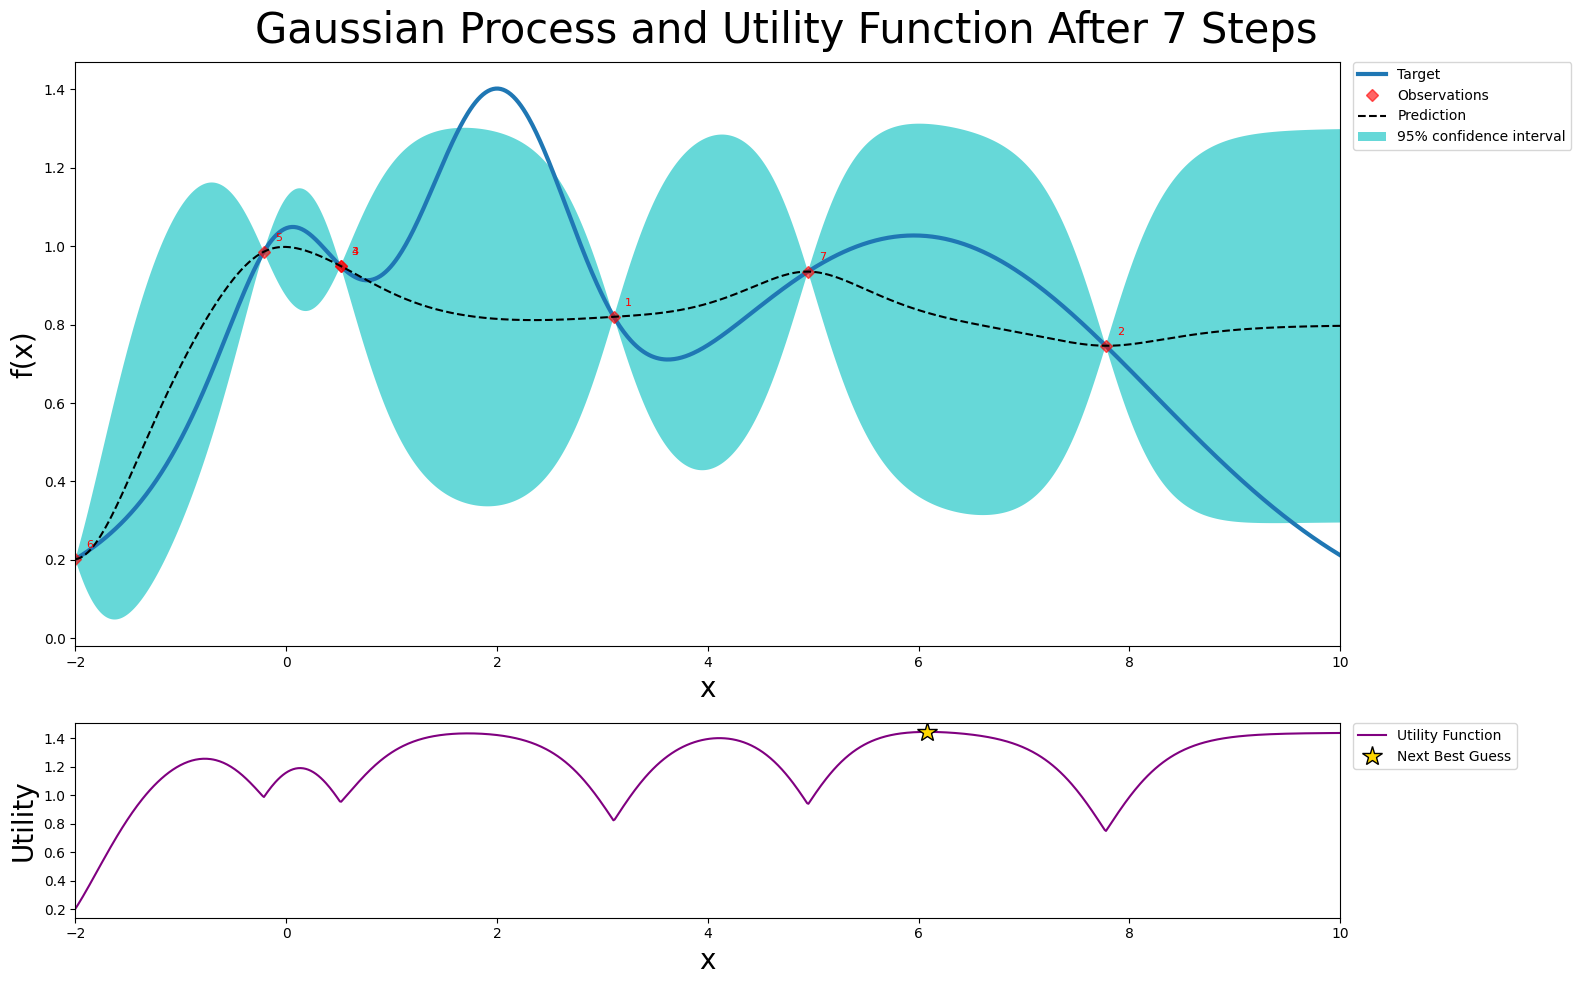

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495500 | 0.5165817 |
| 5         | 0.9526277 | 0.5049405 |
| 6         | 0.9553089 | 0.4950240 |
| 7         | 0.9594185 | 0.4801647 |

Probability of Improvement Acquisition Function Results:


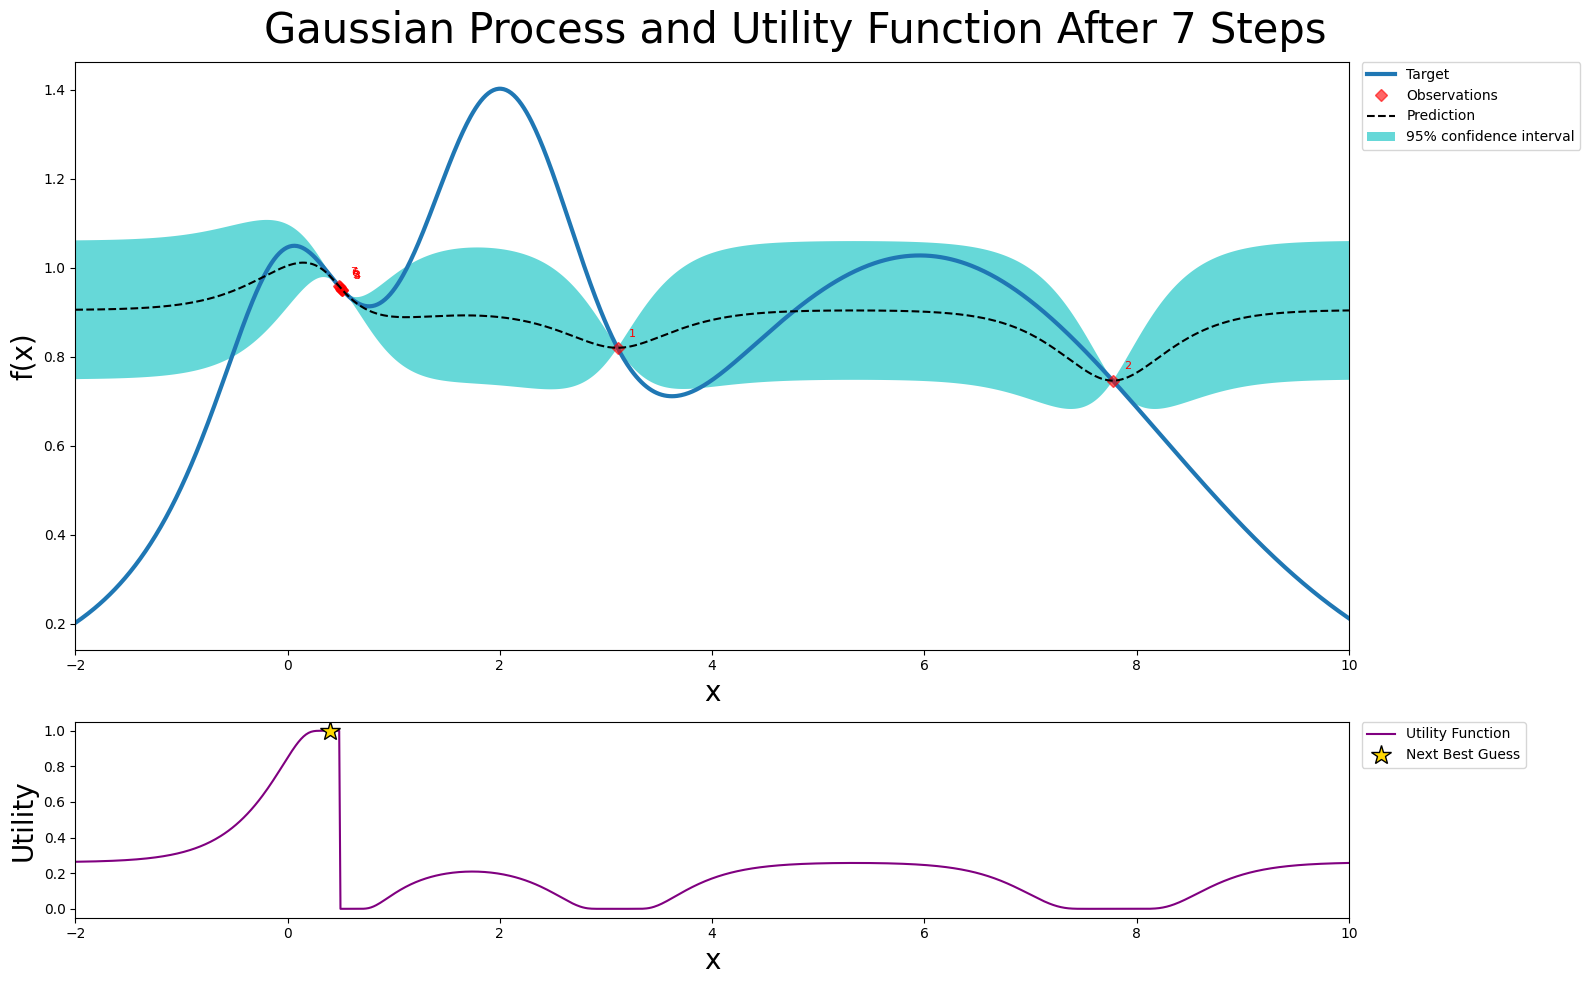

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.4795761 | -1.056368 |
| 5         | 0.5994353 | 8.3148223 |
| 6         | 0.9551109 | 1.0156908 |
| 7         | 0.9990032 | 5.4116415 |
\Chaotic Acquisition Function Results:


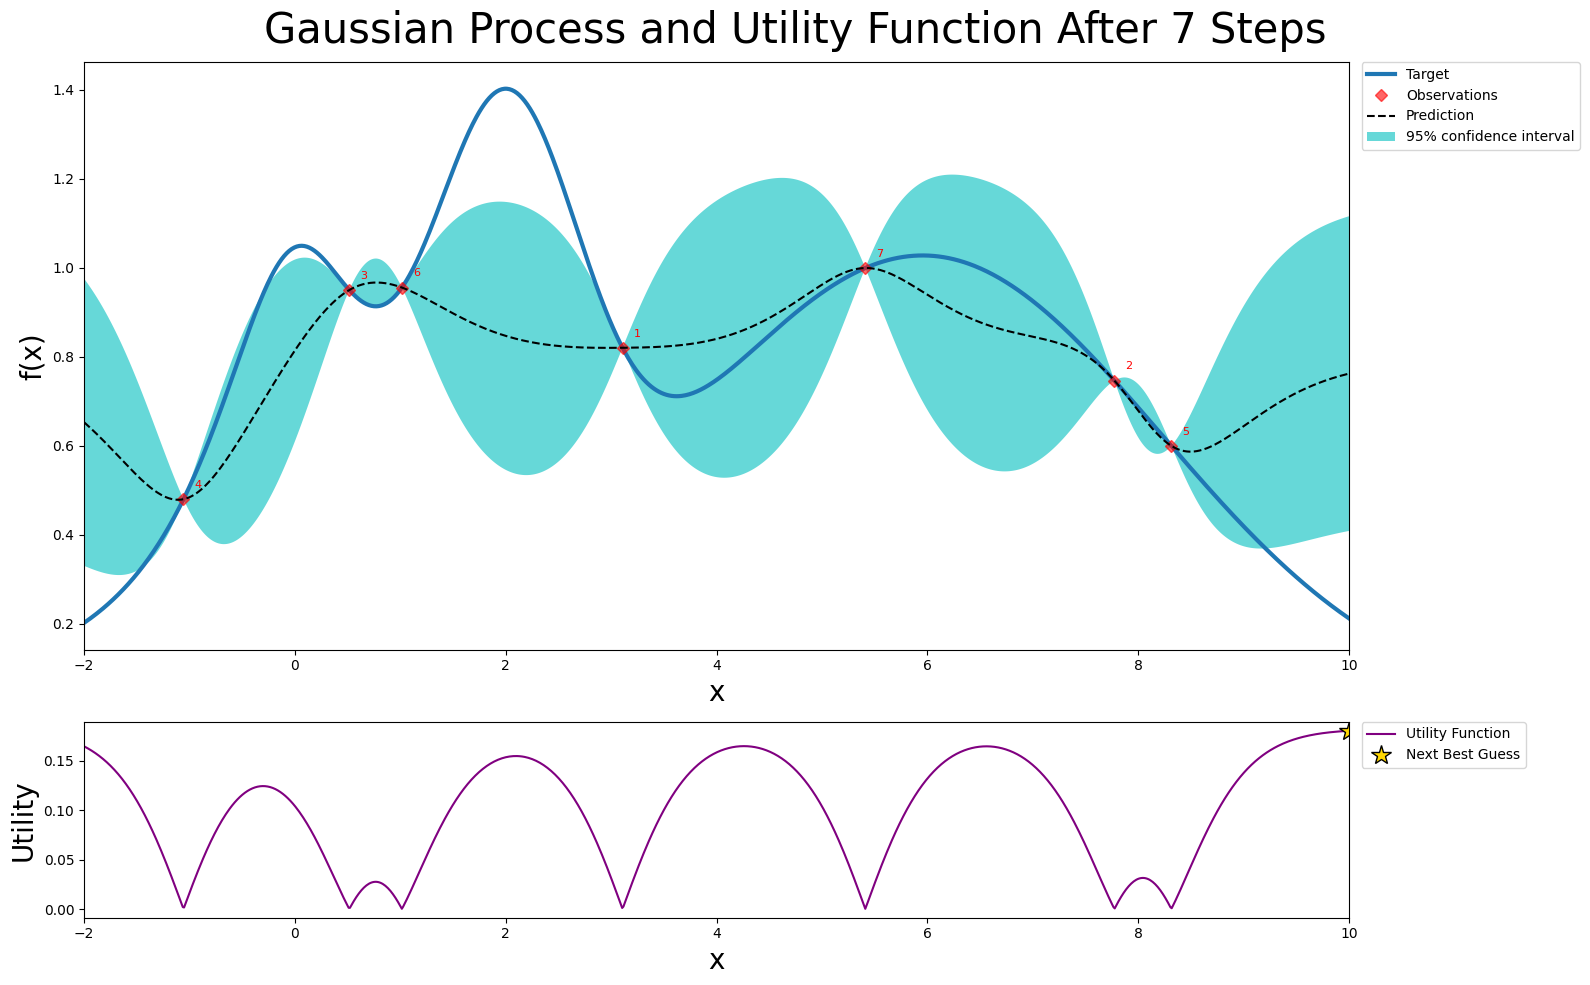


Summary of results:
UCB best value: 0.9857 at x = -0.2118
PI best value: 0.9594 at x = 0.4802
Chaotic best value: 0.9990 at x = 5.4116


In [ ]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

chaotic = ChaoticAcquisition()
optimizer_chaotic = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=chaotic,
    random_state=27,
)

optimizer_chaotic.maximize(init_points=2, n_iter=5)
print("\Chaotic Acquisition Function Results:")
plot_gp(optimizer_chaotic, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Chaotic best value: {optimizer_chaotic.max['target']:.4f} at x = {optimizer_chaotic.max['params']['x']:.4f}"
)

## Comments
The Chaotic acquisition function is worse on the ends of axis prediction but overall creates better fitting in the middle of the range.   
It chose the optimum at the end of the axis, when other methods have chosen local optimas. 

Exercise 3: Expected Improvement
--------------------------------

**Goal:** Implement the Expected Improvement (EI) acquisition function by extending the `AcquisitionFunction` base class provided by the `BayesOpt` library.

Expected Improvement (EI) is a popular choice for the acquisition function. Let's understand its derivation:

1.  **Current Best:** After $n$ evaluations, the best function value observed *so far* is $f^* = \max_{m=1..n} f(x_m)$.

2.  **Potential Improvement:** If we evaluate a new point $x$, the *actual* improvement over the current best $f^*$ is $\max(f(x) - f^*, 0)$, sometimes written as $[f(x) - f^*]^+$.

3.  **The Challenge:** We want to choose $x$ to maximize this improvement, but $f(x)$ is unknown *before* evaluation.

4.  **The Solution: Expected Improvement:** Our probabilistic model gives a posterior distribution for $f(x)$ at any point $x$. Given the data, this is typically a Gaussian distribution: $f(x) \sim \mathcal{N}(\mu_n(x), \sigma_n^2(x))$. EI maximizes the *expected* value of the improvement, where the expectation is taken over this posterior distribution:

    $EI_n(x) = E_n[ \max(f(x) - f^*, 0) ]$

    This value represents, on average, how much we expect to improve upon $f^*$ by evaluating at $x$. The next point chosen is the one that maximizes $EI_n(x)$.

### Mathematical Formulation

The expected improvement integral can be computed analytically. The standard closed-form expression is:

$$
EI(x) =
\begin{cases}
(\mu(x) - f^*) \Phi(Z) + \sigma(x) \varphi(Z) & \text{if } \sigma(x) > 0 \\
0 & \text{if } \sigma(x) = 0
\end{cases}
$$

Where:

* $\mu(x)$: The posterior mean of $f(x)$ at point $x$.
* $\sigma(x)$: The posterior standard deviation of $f(x)$ at point $x$.
* $f^*$: The best function value observed so far (a single scalar value).
* $Z = \frac{\mu(x) - f^*}{\sigma(x)}$
* $\Phi(Z)$: The Cumulative Distribution Function (CDF) of the standard normal distribution $\mathcal{N}(0, 1)$.
* $\varphi(Z)$: The Probability Density Function (PDF) of the standard normal distribution $\mathcal{N}(0, 1)$.

### Implementation Task

Create a class `ExpectedImprovement` inheriting from `acquisition.AcquisitionFunction` and implement the core calculation in the `base_acq` method. The signature of `base_acq` method looks like this:
```python
def base_acq(self, mean: NDArray[Float], std: NDArray[Float]) -> NDArray[Float]:
```

Compare its performance against other acquisition functions.

Hint: Analyse the source code of [ProbabilityOfImprovement](https://github.com/bayesian-optimization/BayesianOptimization/blob/d5126dc2462fddf50047519d6ef6125f271e0650/bayes_opt/acquisition.py#L583) class to better understand how to use/update $f^*$ (`self.y_max`).

In [18]:
from scipy.stats import norm

class ExpectedImprovement(acquisition.AcquisitionFunction):
    """Expected Improvement acquisition function"""

    def __init__(self, random_state=None):
        super().__init__(random_state)
        self.y_max = None

    def base_acq(self, mean: np.ndarray[float], std: np.ndarray[float]) -> np.ndarray[float]:
        """Calculates expected improvement"""
        a = mean - self.y_max
        
        # Calculate Z where std is not too small, avoid division by zero
        Z = np.divide(a, std, where=std > 1e-9, out=np.zeros_like(a))
        
        # Calculate EI where std > 1e-9, else return 0
        ei = np.where(
            std > 1e-9,
            a * norm.cdf(Z) + std * norm.pdf(Z),
            0
        )
        
        return ei
    
    def suggest(
        self,
        gp,
        target_space,
        n_random = 10_000,
        n_smart = 10,
        fit_gp = True,
        random_state = None,
    ):
        y_max = target_space._target_max()
        self.y_max = y_max
        x_max = super().suggest(
            gp=gp,
            target_space=target_space,
            n_random=n_random,
            n_smart=n_smart,
            fit_gp=fit_gp,
            random_state=random_state,
        )
        return x_max

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.7460152 | 7.7750048 |
| 3         | 0.9495499 | 0.5165820 |
| 4         | 0.9495515 | 0.5165758 |
| 5         | 1.0327596 | 0.2129774 |
| 6         | 1.0421903 | -0.026740 |
| 7         | 0.6169669 | -0.804917 |

Expected Improvement Acquisition Function Results:


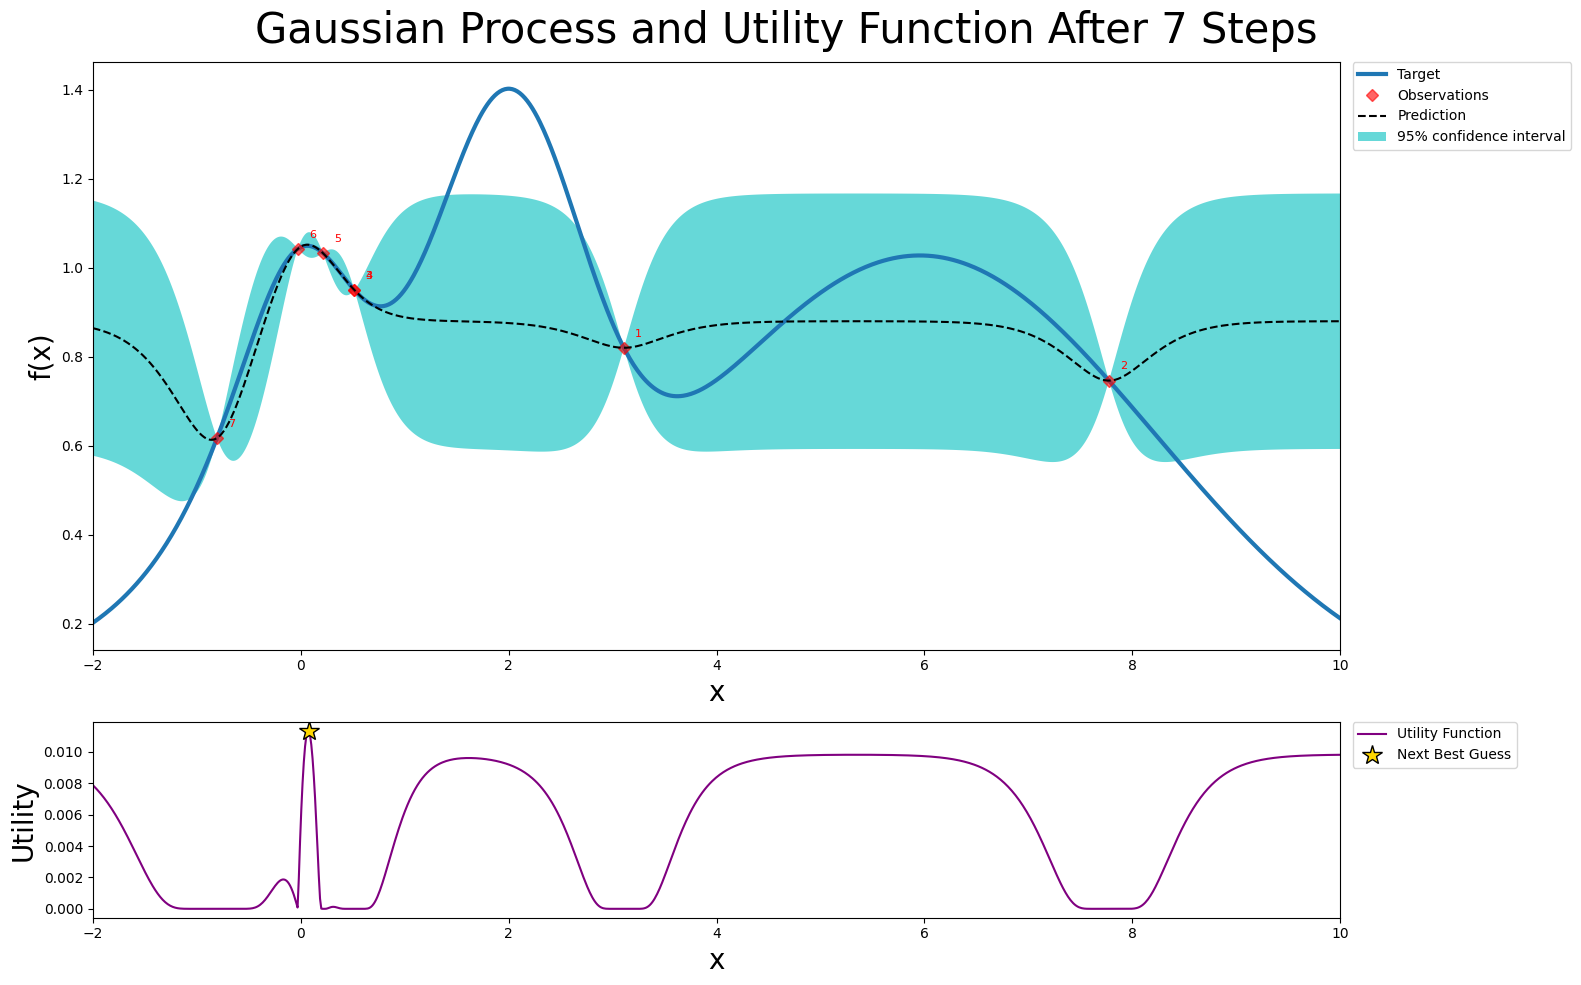


Summary of results:
Expected Improvement best value: 1.0422 at x = -0.0267


In [19]:
ei = ExpectedImprovement()
optimizer_ei = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ei,
    random_state=27,
)

optimizer_ei.maximize(init_points=2, n_iter=5)
print("\nExpected Improvement Acquisition Function Results:")
plot_gp(optimizer_ei, x, y)



# Summary
print("\nSummary of results:")
print(
    f"Expected Improvement best value: {optimizer_ei.max['target']:.4f} at x = {optimizer_ei.max['params']['x']:.4f}"
)

## Comments
EI typically achieves good results by making informed trade-offs between exploration and exploitation. The confidence intervals are quite wide.

# Exercise 4: Theoretical Questions
--------------------------------
1. Why is Bayesian Optimization particularly useful for expensive-to-evaluate functions?

It learns from each test to find the best setting faster, needing fewer expensive evaluations.

2. Compare and contrast the different acquisition functions discussed in this tutorial.

UCB and EI balance exploration and exploitation; PI mainly exploits; Chaotic mainly explores.

3. What are the limitations of Bayesian Optimization?

Choosing the right acquisition function and its parameters (like kappa in UCB) is critical to performance, and different functions work better for different problems as we saw exercices.